<a href="https://colab.research.google.com/github/Raghu3454/sentiment-analysis-cnn/blob/main/Sentiment_Analysis_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow nltk


In [2]:
#load imdb dataset
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

vocab_size = 5000
max_len = 500

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000


In [3]:
#build cnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
#train model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 454ms/step - accuracy: 0.6293 - loss: 0.6087 - val_accuracy: 0.8742 - val_loss: 0.3000
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 444ms/step - accuracy: 0.9067 - loss: 0.2472 - val_accuracy: 0.9010 - val_loss: 0.2497
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 453ms/step - accuracy: 0.9648 - loss: 0.1205 - val_accuracy: 0.8972 - val_loss: 0.2730
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 453ms/step - accuracy: 0.9907 - loss: 0.0465 - val_accuracy: 0.8966 - val_loss: 0.3332
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 447ms/step - accuracy: 0.9971 - loss: 0.0184 - val_accuracy: 0.9022 - val_loss: 0.3743


In [5]:
#evulate model
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.8885 - loss: 0.3970
Test Accuracy: 0.8907999992370605


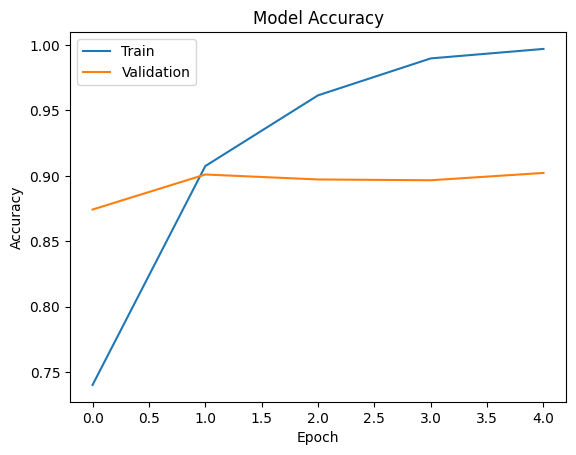

In [6]:
#acuuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


In [7]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.8885 - loss: 0.3970
Test Accuracy: 0.8907999992370605
